# Consumer Behavior Under Economic Pressure

## TL;DR

Using 360 country-month observations with valid year-on-year retail growth, the evidence is mixed rather than a single inflation story. Pooled inflation correlations were negative for total growth (Pearson **-0.250**, Spearman **-0.365**), but the adjusted total-growth coefficient was close to zero (**-0.046**, 95% CI [-0.342, 0.250]). The clearest inflation result was for food growth (**-0.786**, [-0.981, -0.591]).

Confidence was positively associated with total growth (**0.195**, [0.089, 0.302]) and non-food growth (**0.309**, [0.148, 0.470]) in the pooled adjusted models. The category interaction test found stronger confidence sensitivity for non-food, but inflation was more negatively associated with food—not non-food. Country estimates differed, and COVID/reopening observations materially affected some coefficients. These are observational associations, not causal effects.

## 1. Research Questions & Hypotheses

The questions and expectations were fixed before reviewing results:

- **RQ1 / H1:** Is higher inflation associated with weaker real retail-sales volume growth?
- **RQ2 / H2:** Is higher consumer confidence associated with stronger growth?
- **RQ3 / H3:** Is non-food growth more sensitive to inflation and confidence than food growth?
- **RQ4:** Do these relationships differ across the Netherlands, Germany, and France?

H1–H3 are hypotheses to test, not conclusions to prove. Retail measures are Eurostat volume-of-sales indices and therefore real retail-activity proxies—not nominal expenditure or total household consumption.

## 2. Analytical Dataset

The Phase 1 master dataset is the source of truth. This notebook does not download, rebuild, impute, or overwrite it. Models use only the pre-specified year-on-year retail-growth outcomes; raw retail index levels are limited to descriptive context.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

candidate = Path.cwd().resolve()
if not (candidate / "data" / "processed").exists():
    candidate = candidate.parent
PROJECT_ROOT = candidate
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from phase2_analysis import OUTCOMES, PREDICTORS, run_analysis

results = run_analysis()
data = results["data"]

assert len(data) == 396
assert data.duplicated(["country_code", "date"]).sum() == 0
assert all(data[outcome].notna().sum() == 360 for outcome in OUTCOMES)
print(f"Master rows: {len(data)}; countries: {sorted(data.country_code.unique())}")
print(f"Period: {data.date.min().date()} to {data.date.max().date()}")
print(f"Primary outcomes: {OUTCOMES}")
print(f"Primary predictors: {PREDICTORS}")

Master rows: 396; countries: ['DE', 'FR', 'NL']
Period: 2015-01-01 to 2025-12-01
Primary outcomes: ['retail_total_yoy', 'retail_food_yoy', 'retail_nonfood_yoy']
Primary predictors: ['inflation_yoy', 'consumer_confidence']


## 3. Descriptive Statistics

The first 12 structural YoY blanks per country are excluded automatically. The overall table and compact country table report valid N, center, spread, quartiles, and range.

In [2]:
display(results["descriptive_overall"].round(3))
display(
    results["descriptive_by_country"]
    .loc[:, ["country_code", "variable", "n", "mean", "median", "std", "min", "max"]]
    .round(3)
)

,scope,variable,n,mean,median,std,min,p25,p75,max
0,Pooled descriptive,inflation_yoy,396,2.526,1.700,2.754,-1.000,0.875,2.925,17.100
1,Pooled descriptive,consumer_confidence,396,-8.951,-9.250,7.697,-35.900,-14.000,-2.200,7.100
2,Pooled descriptive,retail_total_yoy,360,2.018,2.219,4.738,-30.876,0.462,3.622,43.586
3,Pooled descriptive,retail_food_yoy,360,0.690,1.076,3.465,-9.700,-1.029,2.670,13.732
4,Pooled descriptive,retail_nonfood_yoy,360,3.387,3.254,7.752,-46.499,0.932,5.632,77.096


,country_code,variable,n,mean,median,std,min,max
0,NL,inflation_yoy,132,2.897,1.900,3.353,-1.000,17.100
1,NL,consumer_confidence,132,-8.176,-7.400,9.375,-35.900,7.100
2,NL,retail_total_yoy,120,1.686,2.052,3.206,-9.015,12.788
3,NL,retail_food_yoy,120,-0.308,-0.214,3.308,-8.283,9.091
4,NL,retail_nonfood_yoy,120,3.394,3.434,5.642,-17.653,27.059
5,DE,inflation_yoy,132,2.646,1.950,2.675,-0.700,11.600
6,DE,consumer_confidence,132,-6.713,-3.900,7.249,-28.000,2.300
7,DE,retail_total_yoy,120,1.708,1.889,3.681,-7.239,14.729
8,DE,retail_food_yoy,120,0.541,0.806,3.676,-9.700,11.297
9,DE,retail_nonfood_yoy,120,2.638,2.786,5.646,-16.684,29.172


## 4. Time-Series Exploration

The shaded window marks March 2020–December 2021 descriptively. Those observations remain in every primary analysis.

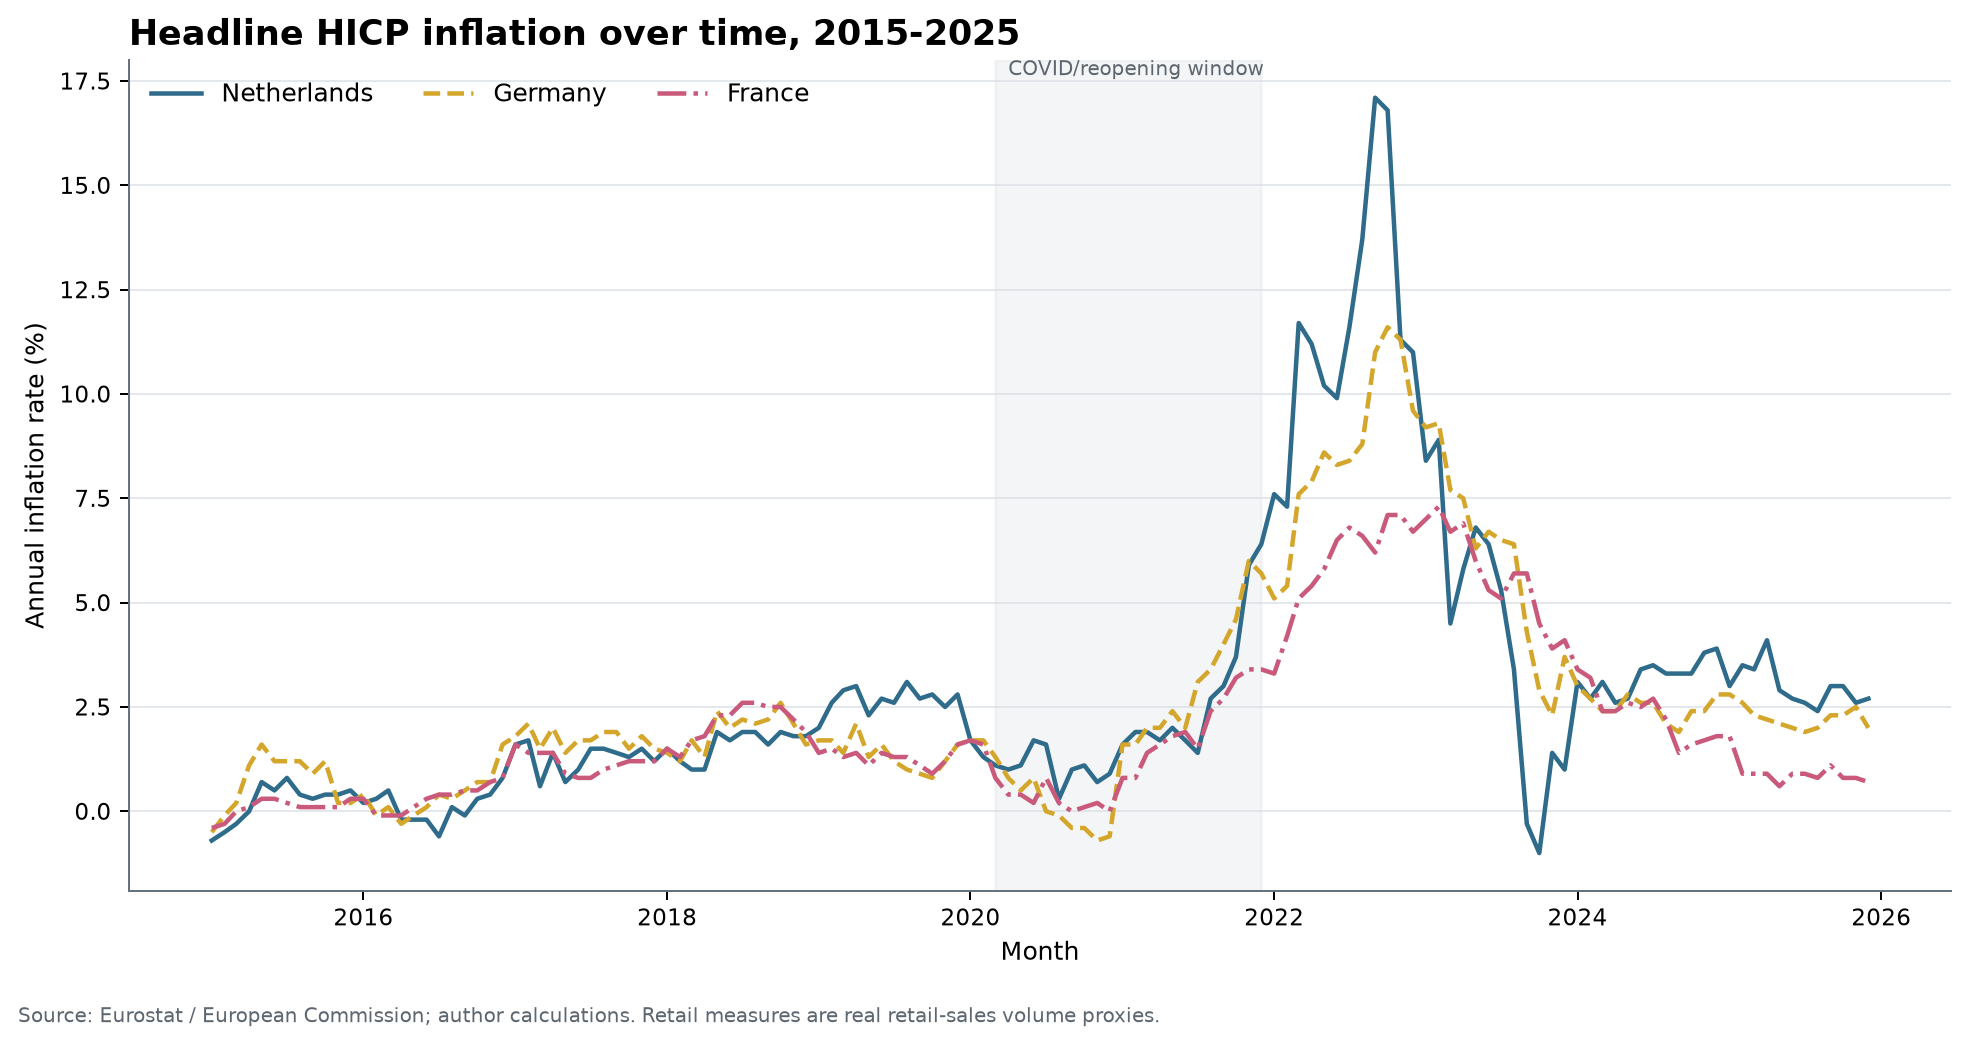

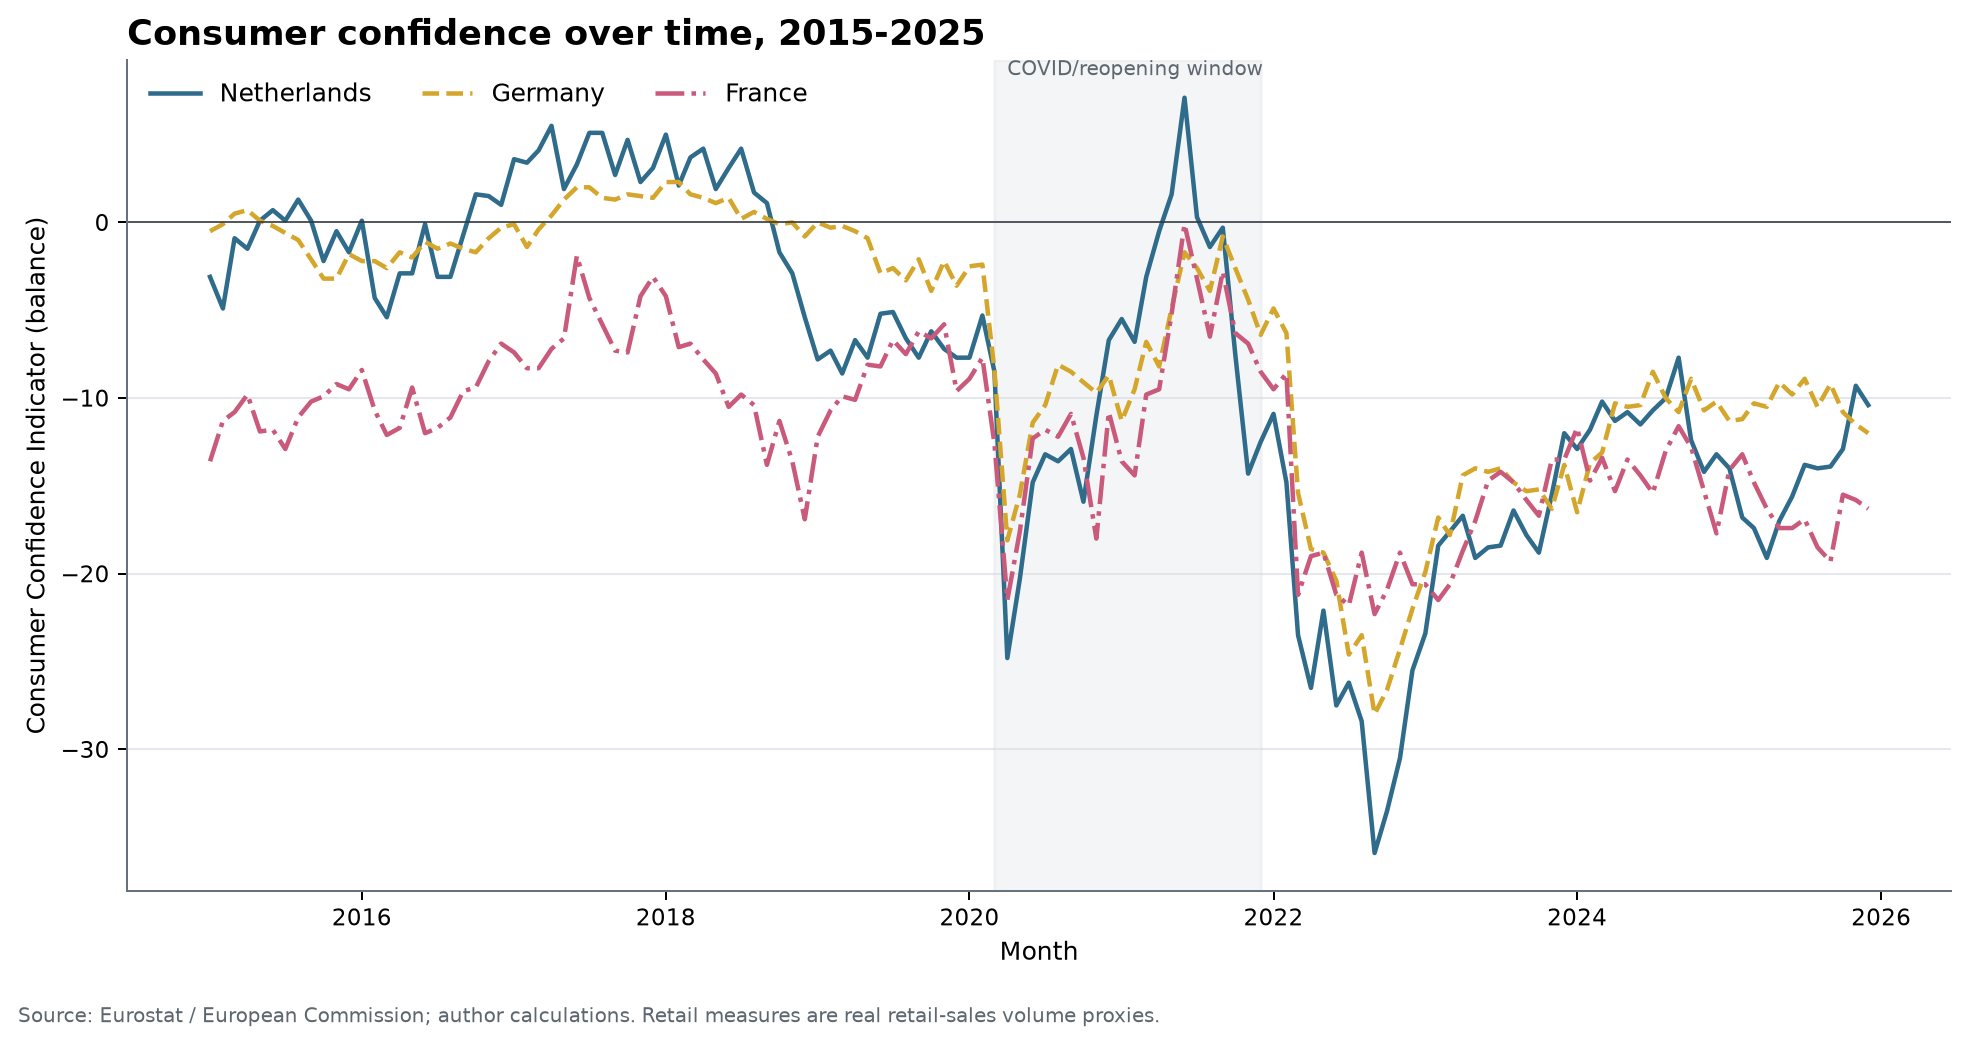

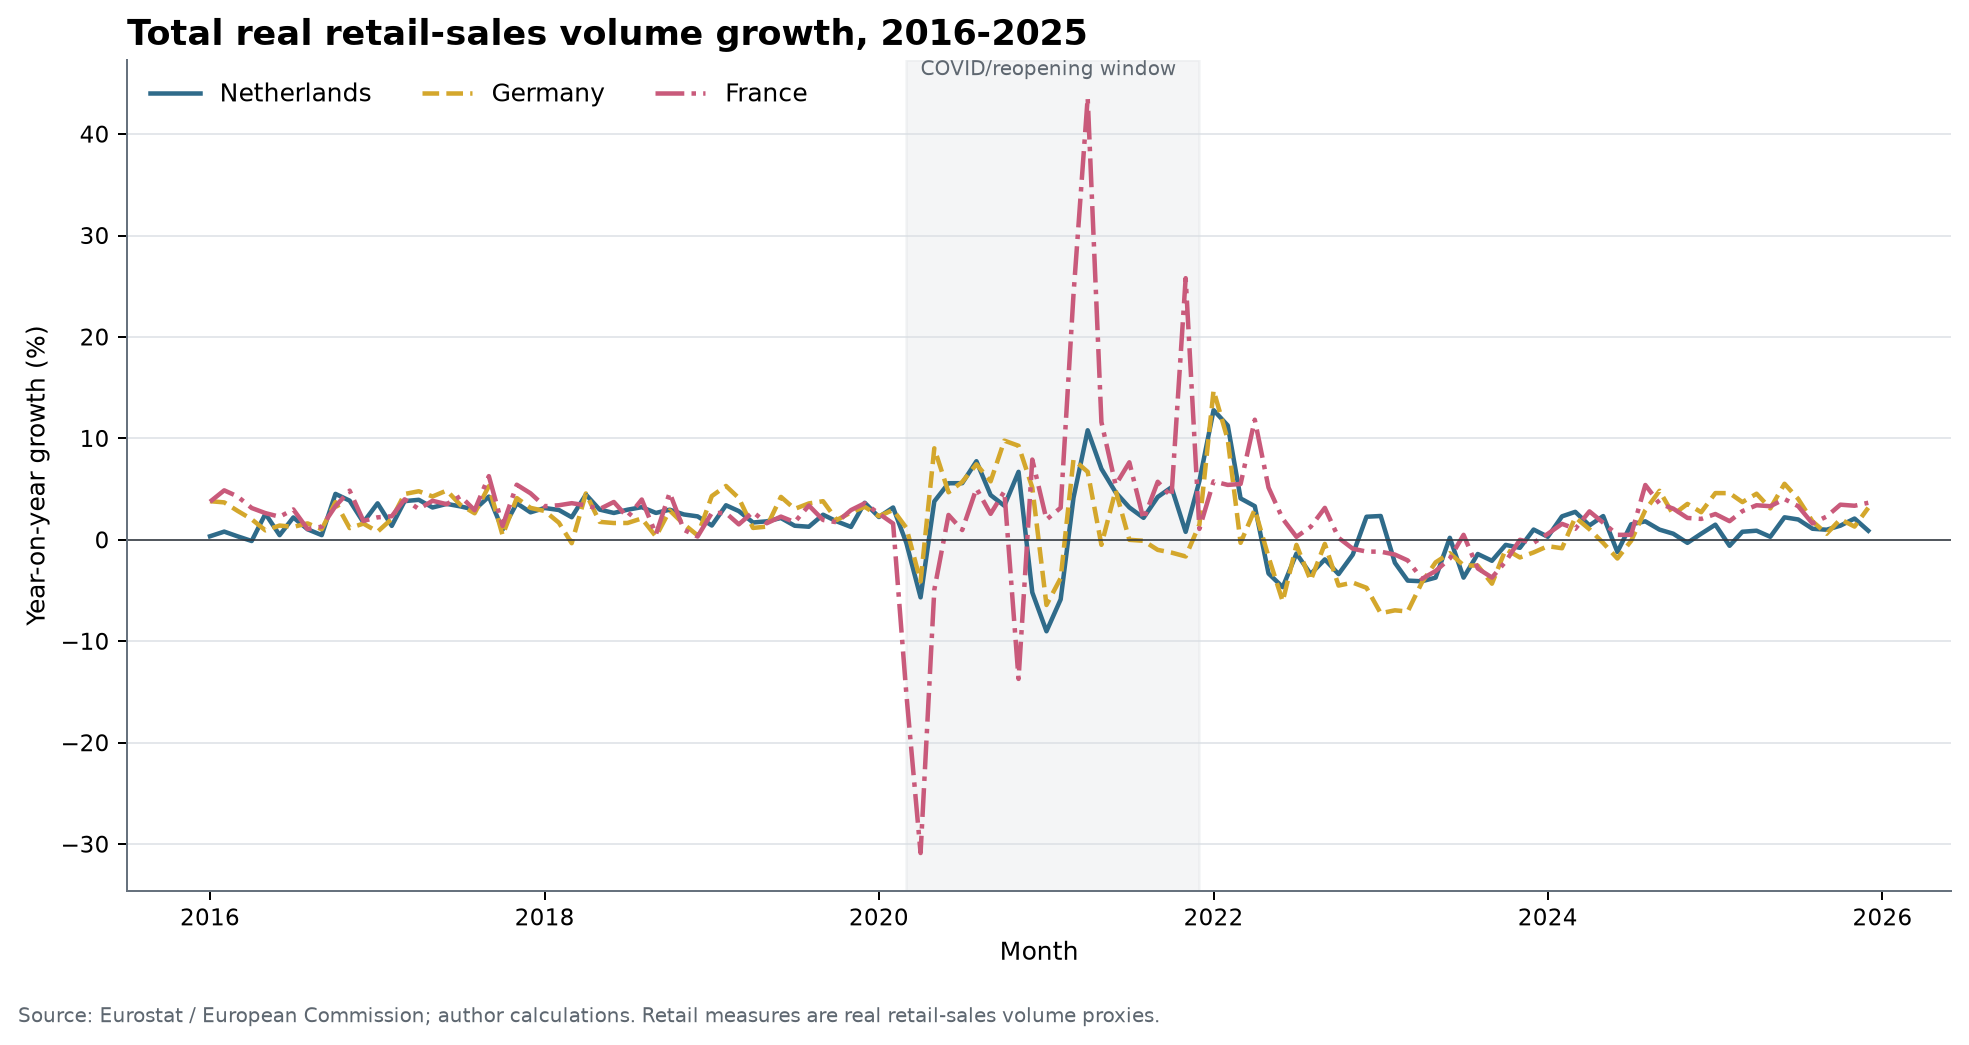

In [3]:
for filename in [
    "inflation_over_time.png",
    "consumer_confidence_over_time.png",
    "retail_total_yoy_over_time.png",
]:
    display(Image(filename=str(PROJECT_ROOT / "outputs" / "figures" / filename), width=950))

## 5. Food vs Non-Food Patterns

Non-food growth is visibly more volatile, particularly during pandemic and reopening months. The shared vertical scale in the small multiples preserves honest cross-country magnitude comparisons.

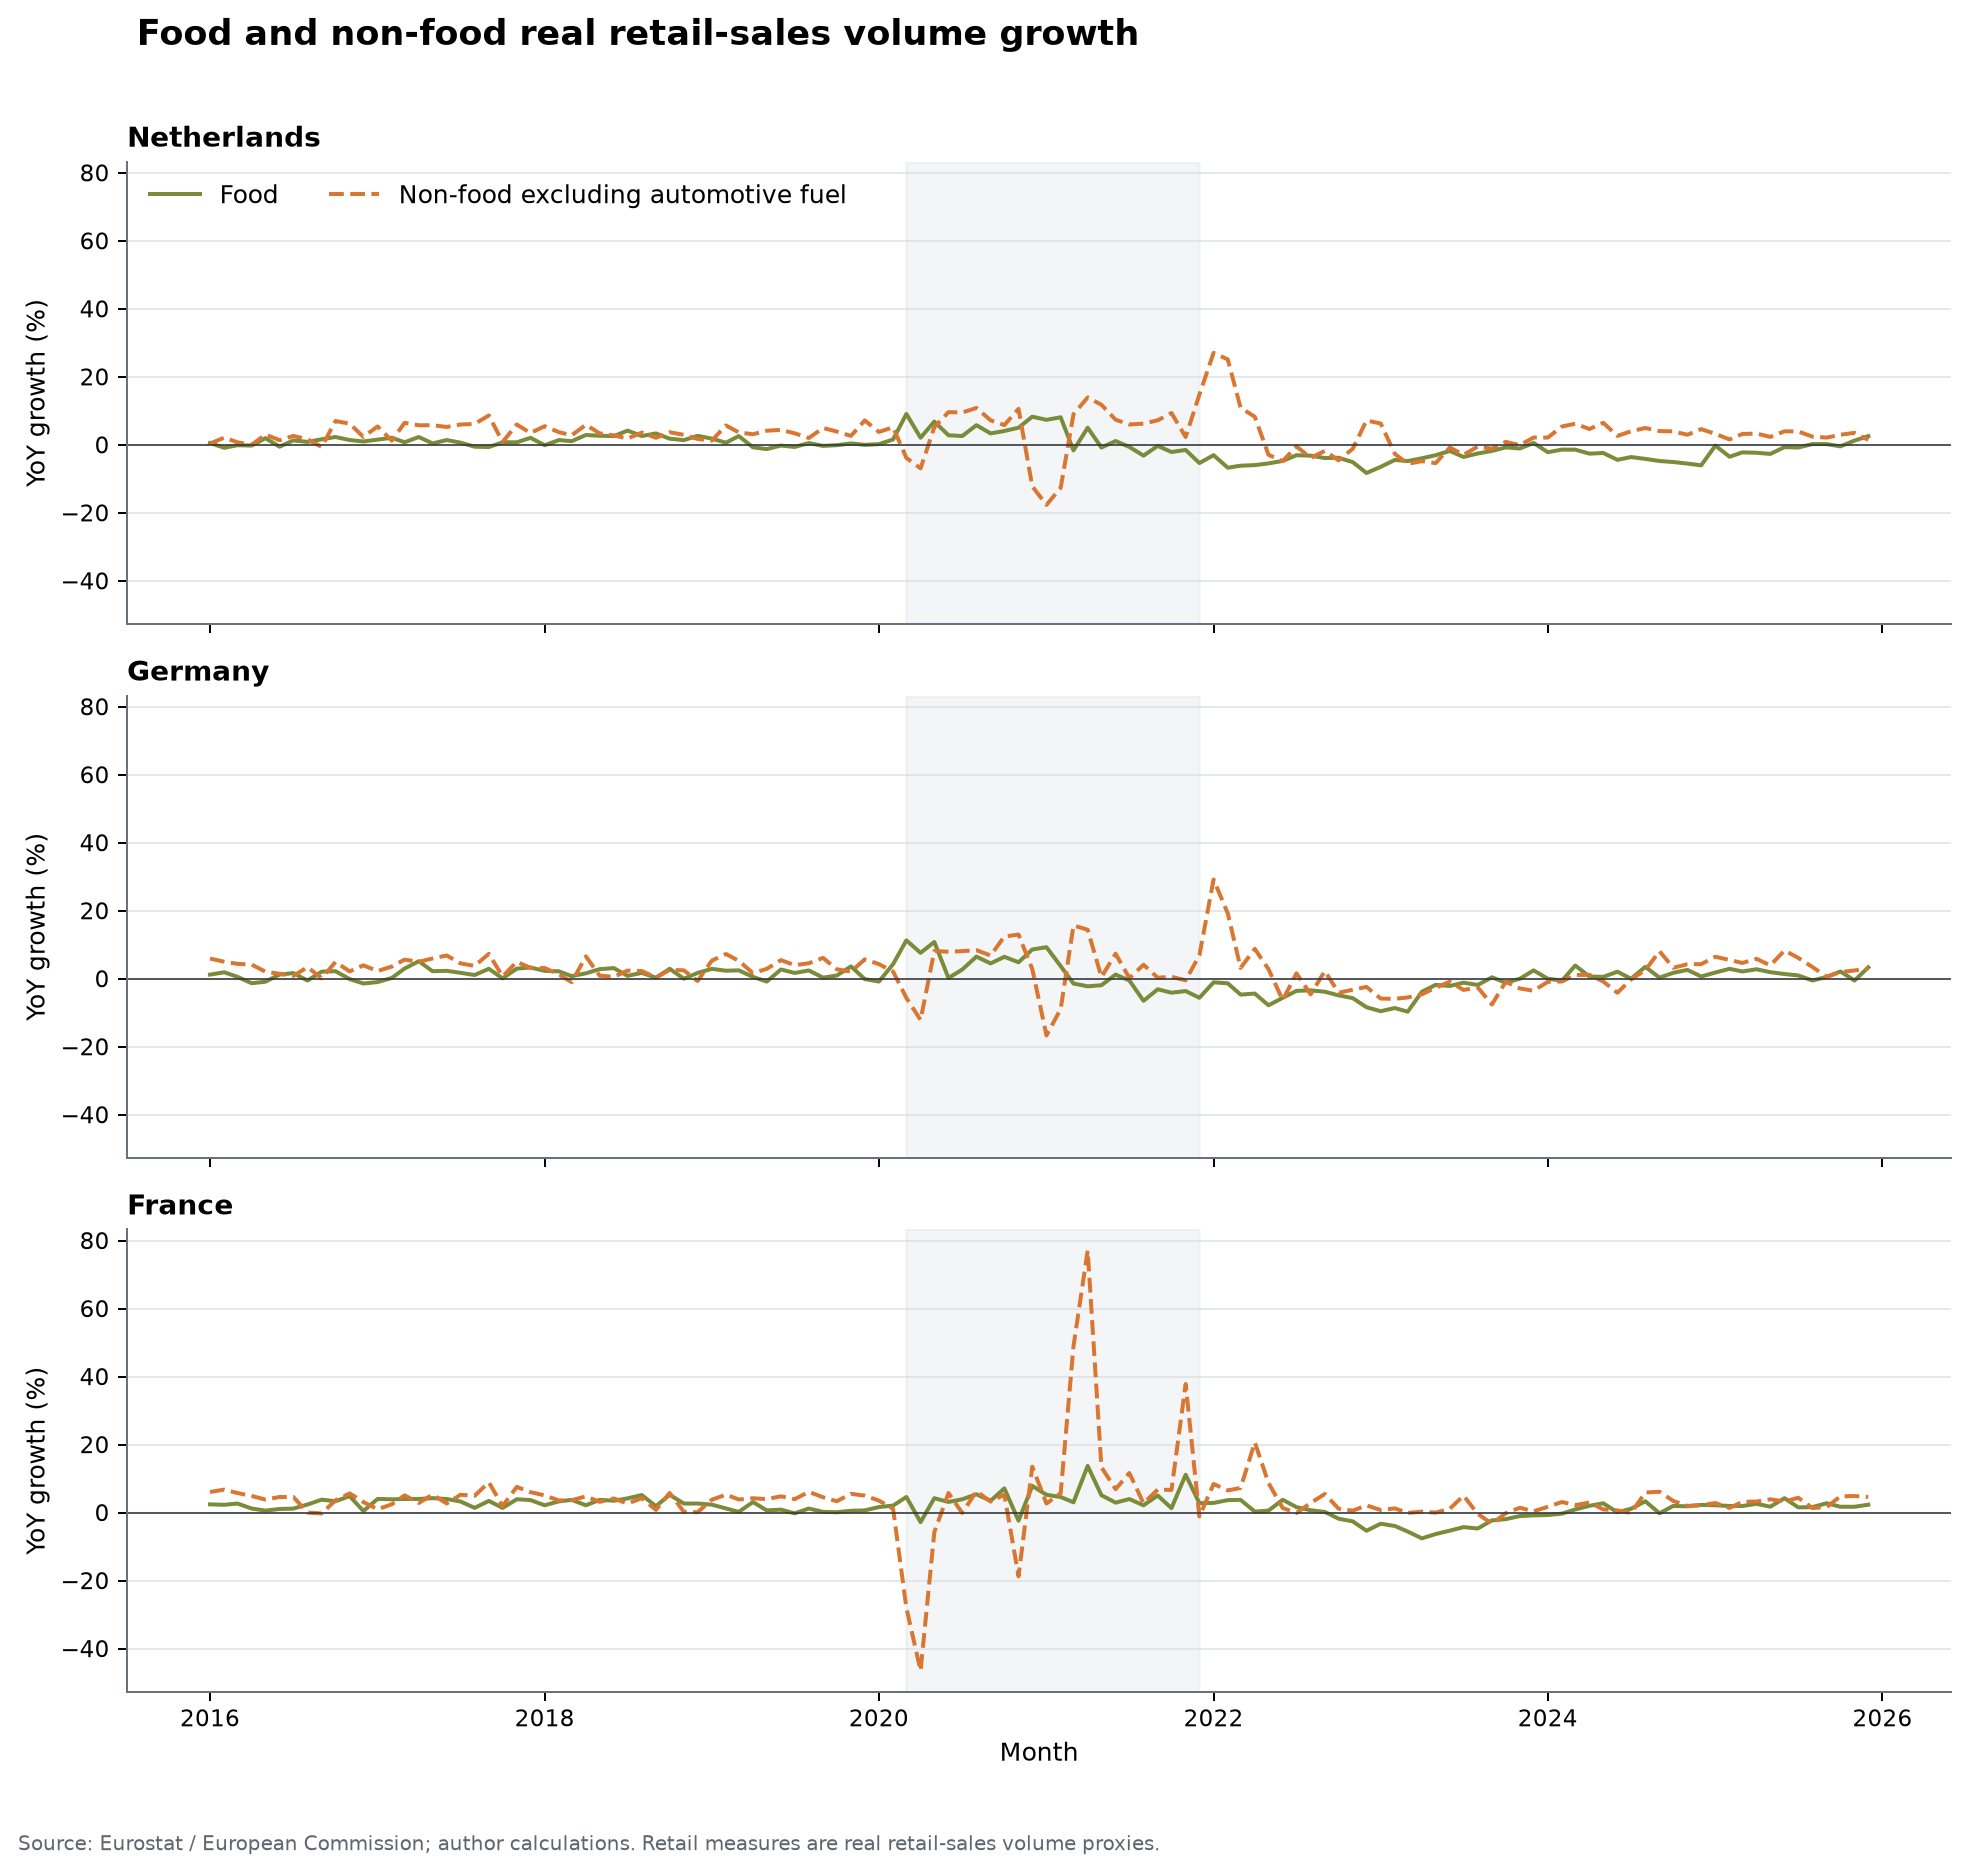

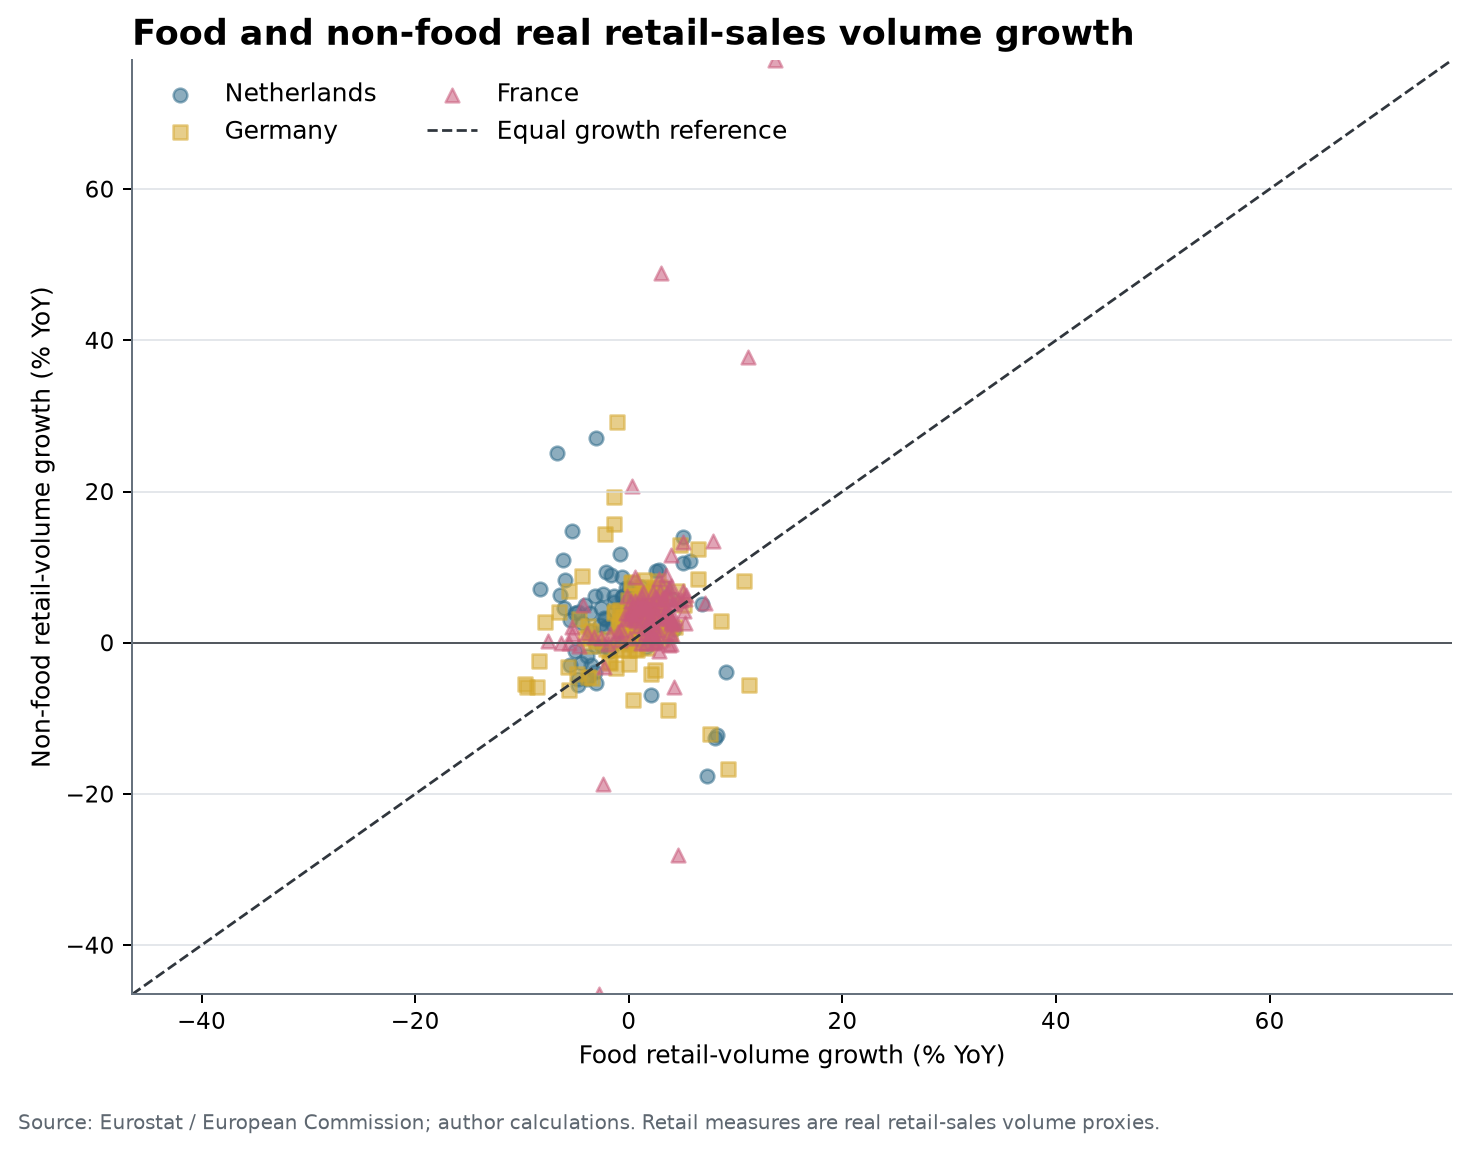

In [4]:
for filename in [
    "food_vs_nonfood_yoy_by_country.png",
    "food_vs_nonfood_growth_comparison.png",
]:
    display(Image(filename=str(PROJECT_ROOT / "outputs" / "figures" / filename), width=950))

## 6. Correlation Analysis

Pearson measures linear association; Spearman measures monotonic rank association and is less dominated by extreme magnitudes. Pooled correlations are descriptive because repeated monthly observations are not independent.

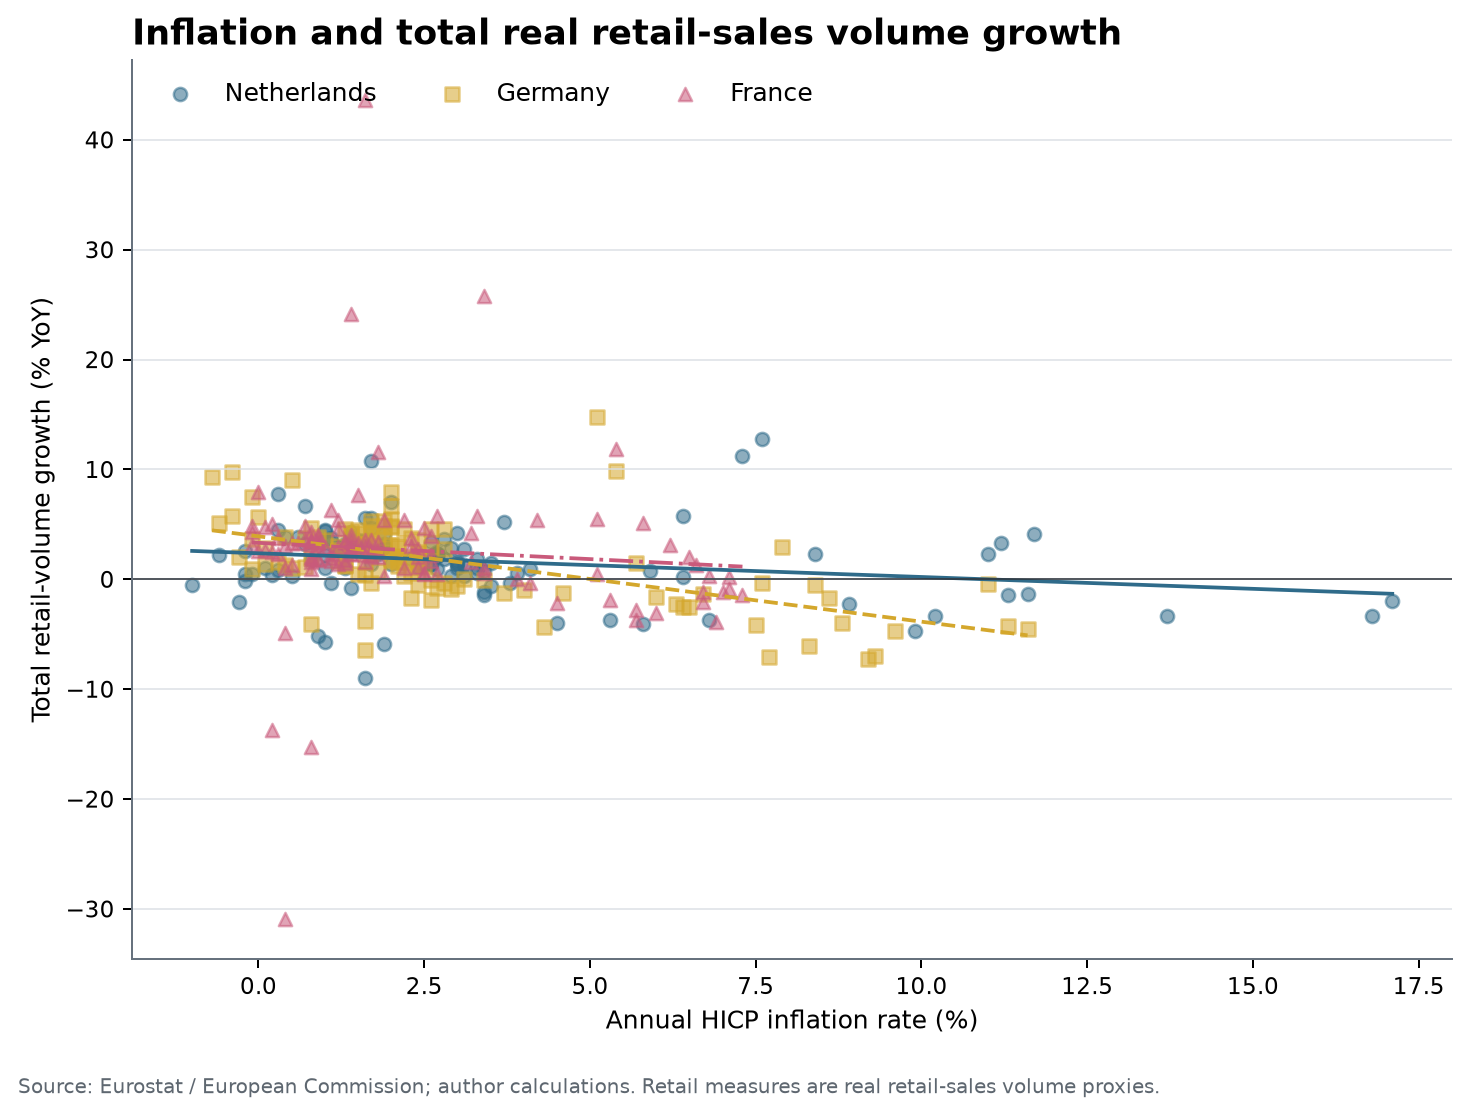

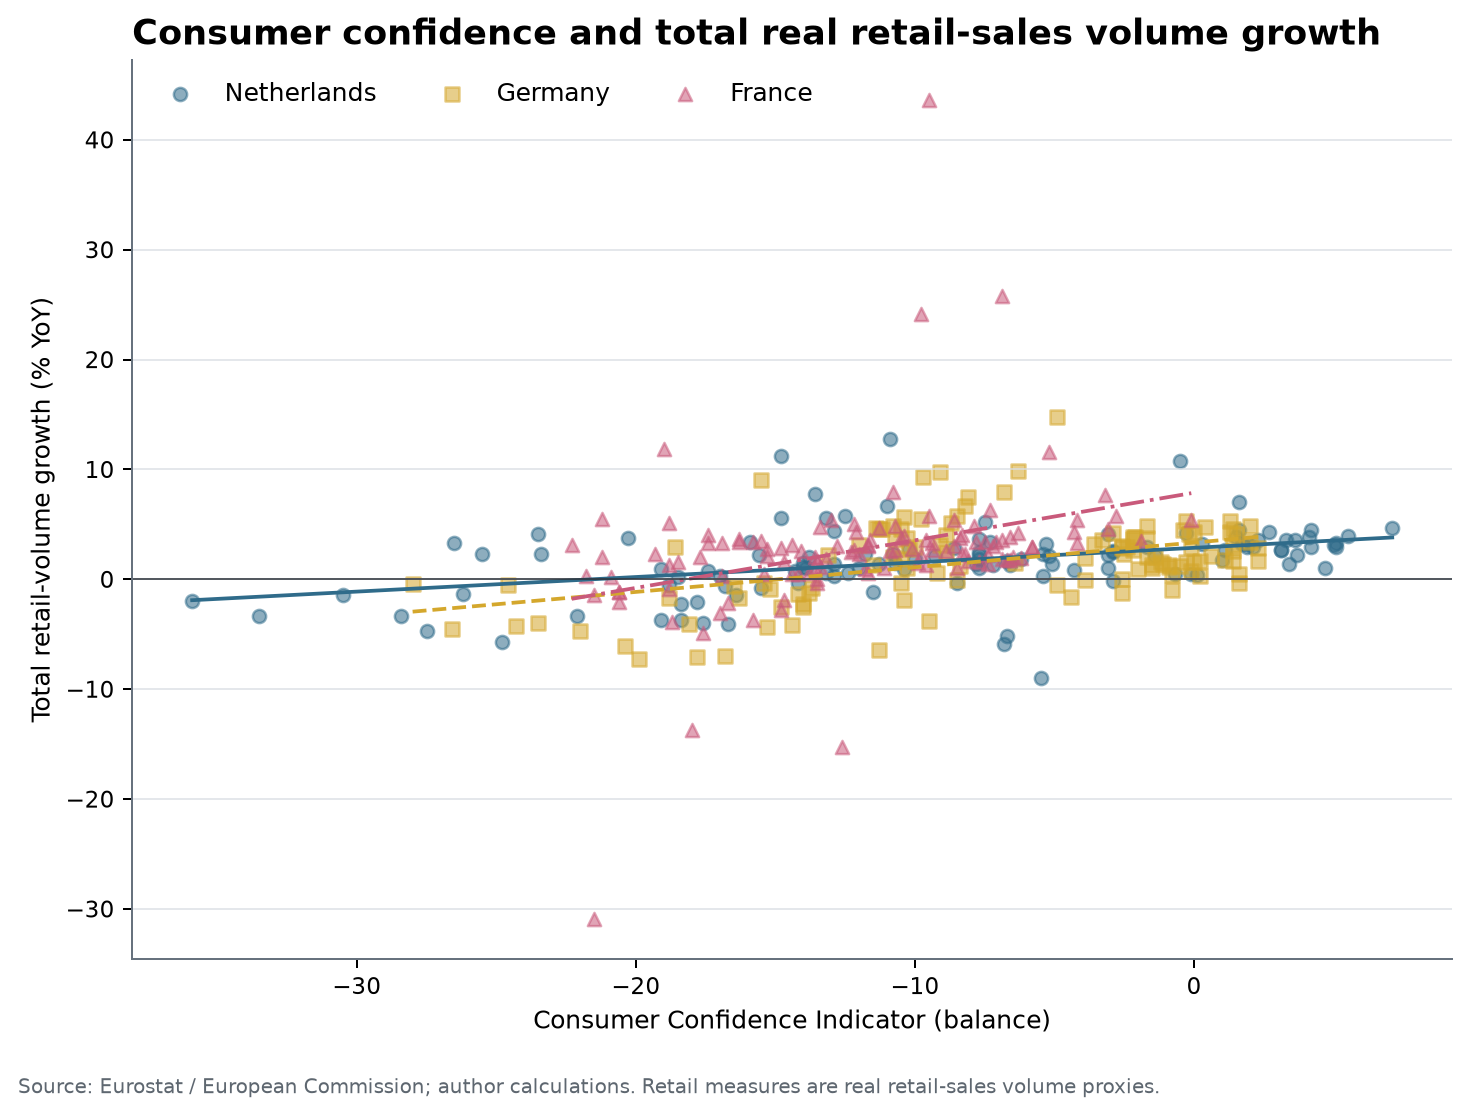

In [5]:
pearson_compact = results["pearson"].pivot_table(
    index=["scope", "predictor"], columns="outcome", values="coefficient"
).round(3)
spearman_compact = results["spearman"].pivot_table(
    index=["scope", "predictor"], columns="outcome", values="coefficient"
).round(3)
display(pearson_compact.style.set_caption("Pearson correlations"))
display(spearman_compact.style.set_caption("Spearman correlations"))

for filename in ["inflation_vs_total_retail_growth.png", "confidence_vs_total_retail_growth.png"]:
    display(Image(filename=str(PROJECT_ROOT / "outputs" / "figures" / filename), width=800))

## 7. Lag Analysis

Lag 0–3 associations are exploratory and all are retained. A stronger lag is not presented as pre-specified or predictive.

In [6]:
pooled_lags = results["lags"].loc[
    results["lags"]["scope"].eq("Pooled"),
    ["predictor", "lag_months", "outcome", "n", "pearson_r", "spearman_rho"],
]
country_total_lags = results["lags"].loc[
    results["lags"]["scope"].ne("Pooled") & results["lags"]["outcome"].eq("retail_total_yoy"),
    ["scope", "predictor", "lag_months", "n", "pearson_r", "spearman_rho"],
]
display(pooled_lags.round(3))
display(country_total_lags.round(3))
print("Complete country x outcome x lag results: outputs/tables/lag_correlations.csv")

,predictor,lag_months,outcome,n,pearson_r,spearman_rho
0,inflation,0,retail_total_yoy,360,-0.250,-0.365
1,inflation,0,retail_food_yoy,360,-0.646,-0.575
2,inflation,0,retail_nonfood_yoy,360,-0.097,-0.223
3,inflation,1,retail_total_yoy,360,-0.269,-0.360
4,inflation,1,retail_food_yoy,360,-0.658,-0.576
5,inflation,1,retail_nonfood_yoy,360,-0.117,-0.223
6,inflation,2,retail_total_yoy,360,-0.295,-0.375
7,inflation,2,retail_food_yoy,360,-0.659,-0.565
8,inflation,2,retail_nonfood_yoy,360,-0.144,-0.249
9,inflation,3,retail_total_yoy,360,-0.324,-0.405


,scope,predictor,lag_months,n,pearson_r,spearman_rho
24,NL,inflation,0,120,-0.229,-0.251
27,NL,inflation,1,120,-0.254,-0.252
30,NL,inflation,2,120,-0.292,-0.285
33,NL,inflation,3,120,-0.341,-0.380
36,NL,consumer_confidence,0,120,0.395,0.463
39,NL,consumer_confidence,1,120,0.350,0.427
42,NL,consumer_confidence,2,120,0.351,0.437
45,NL,consumer_confidence,3,120,0.388,0.482
48,DE,inflation,0,120,-0.575,-0.544
51,DE,inflation,1,120,-0.567,-0.496


Complete country x outcome x lag results: outputs/tables/lag_correlations.csv


## 8. Primary Regression Models

Each pooled model estimates retail YoY growth on contemporaneous inflation and confidence plus country indicators. HC3 standard errors follow the pre-specified design. Coefficients remain associational.

In [7]:
pooled_primary = results["pooled_table"].loc[
    results["pooled_table"]["term"].isin(PREDICTORS),
    ["outcome", "term", "coefficient", "standard_error", "ci_lower_95", "ci_upper_95", "p_value", "n", "r_squared", "adjusted_r_squared"],
]
display(pooled_primary.round(4))

standardized = results["standardized_table"].loc[
    results["standardized_table"]["term"].isin(["z_inflation_yoy", "z_consumer_confidence"]),
    ["outcome", "term", "coefficient", "ci_lower_95", "ci_upper_95"],
]
display(standardized.round(3).style.set_caption("Secondary models: predictors standardized, outcomes in percentage points"))

,outcome,term,coefficient,standard_error,ci_lower_95,ci_upper_95,p_value,n,r_squared,adjusted_r_squared
3,retail_total_yoy,inflation_yoy,-0.0460,0.1508,-0.3415,0.2495,0.7604,360,0.1172,0.1073
4,retail_total_yoy,consumer_confidence,0.1953,0.0545,0.0885,0.3021,0.0003,360,0.1172,0.1073
8,retail_food_yoy,inflation_yoy,-0.7859,0.0993,-0.9806,-0.5912,0.0000,360,0.4452,0.4389
9,retail_food_yoy,consumer_confidence,-0.0067,0.0278,-0.0612,0.0478,0.8102,360,0.4452,0.4389
13,retail_nonfood_yoy,inflation_yoy,0.3214,0.2327,-0.1347,0.7775,0.1672,360,0.0619,0.0513
14,retail_nonfood_yoy,consumer_confidence,0.3090,0.0823,0.1477,0.4702,0.0002,360,0.0619,0.0513


,outcome,term,coefficient,ci_lower_95,ci_upper_95
3,retail_total_yoy,z_inflation_yoy,-0.128000,-0.953000,0.696000
4,retail_total_yoy,z_consumer_confidence,1.518000,0.688000,2.348000
8,retail_food_yoy,z_inflation_yoy,-2.192000,-2.735000,-1.649000
9,retail_food_yoy,z_consumer_confidence,-0.052000,-0.475000,0.372000
13,retail_nonfood_yoy,z_inflation_yoy,0.897000,-0.376000,2.169000
14,retail_nonfood_yoy,z_consumer_confidence,2.401000,1.148000,3.655000


## 9. Country-Level Results

Separate country models use Newey-West/HAC standard errors with `maxlags=3`. Coefficient differences are compared descriptively rather than used to rank countries.

In [8]:
country_primary = results["country_table"].loc[
    results["country_table"]["term"].isin(PREDICTORS),
    ["scope", "outcome", "term", "coefficient", "standard_error", "ci_lower_95", "ci_upper_95", "p_value", "n", "r_squared"],
]
display(country_primary.round(4))

,scope,outcome,term,coefficient,standard_error,ci_lower_95,ci_upper_95,p_value,n,r_squared
1,NL,retail_total_yoy,inflation_yoy,0.1231,0.2023,-0.2734,0.5195,0.5430,120,0.1637
2,NL,retail_total_yoy,consumer_confidence,0.1650,0.0544,0.0583,0.2716,0.0024,120,0.1637
4,NL,retail_food_yoy,inflation_yoy,-0.5394,0.2036,-0.9384,-0.1404,0.0081,120,0.3977
5,NL,retail_food_yoy,consumer_confidence,0.0344,0.0582,-0.0797,0.1486,0.5542,120,0.3977
7,NL,retail_nonfood_yoy,inflation_yoy,0.3266,0.3945,-0.4465,1.0998,0.4076,120,0.0603
8,NL,retail_nonfood_yoy,consumer_confidence,0.2071,0.0888,0.0331,0.3812,0.0196,120,0.0603
10,DE,retail_total_yoy,inflation_yoy,-0.6907,0.2517,-1.1840,-0.1974,0.0061,120,0.3346
11,DE,retail_total_yoy,consumer_confidence,0.0458,0.0751,-0.1015,0.1930,0.5426,120,0.3346
13,DE,retail_food_yoy,inflation_yoy,-1.2826,0.1643,-1.6047,-0.9606,0.0000,120,0.5965
14,DE,retail_food_yoy,consumer_confidence,-0.1486,0.0553,-0.2570,-0.0402,0.0072,120,0.5965


## 10. Food vs Non-Food Interaction Test

The long-format model contains paired food and non-food observations for each country-month. Standard errors are clustered at country-month level. Interaction coefficients directly test whether slopes differ by category.

In [9]:
interaction_terms = [
    "inflation_yoy:is_nonfood", "consumer_confidence:is_nonfood",
    "food_inflation_slope", "nonfood_inflation_slope",
    "food_confidence_slope", "nonfood_confidence_slope",
]
interaction_display = results["interaction_table"].loc[
    results["interaction_table"]["term"].isin(interaction_terms),
    ["term", "effect_type", "coefficient", "standard_error", "ci_lower_95", "ci_upper_95", "p_value", "category_observations", "country_month_clusters"],
]
display(interaction_display.round(4))

,term,effect_type,coefficient,standard_error,ci_lower_95,ci_upper_95,p_value,category_observations,country_month_clusters
6,inflation_yoy:is_nonfood,model_parameter,0.9861,0.2293,0.5366,1.4356,0.0000,720,360
7,consumer_confidence:is_nonfood,model_parameter,0.2585,0.0726,0.1162,0.4008,0.0004,720,360
8,food_inflation_slope,derived_category_slope,-0.7253,0.0998,-0.9209,-0.5297,0.0000,720,360
9,nonfood_inflation_slope,derived_category_slope,0.2608,0.2264,-0.1829,0.7045,0.2493,720,360
10,food_confidence_slope,derived_category_slope,0.0219,0.0309,-0.0386,0.0824,0.4783,720,360
11,nonfood_confidence_slope,derived_category_slope,0.2804,0.0781,0.1272,0.4335,0.0003,720,360


## 11. Model Diagnostics

Diagnostics examine residual shape, heteroskedasticity, serial dependence, multicollinearity, and influence. Extreme observations are documented—not automatically removed.

In [10]:
diagnostic_focus = results["diagnostics"].loc[
    results["diagnostics"]["diagnostic"].isin([
        "jarque_bera_p_value", "breusch_pagan_p_value", "durbin_watson",
        "breusch_godfrey_lag3_p_value", "max_cooks_distance",
        "count_cooks_gt_4_over_n", "vif_inflation_yoy", "vif_consumer_confidence",
    ])
]
display(diagnostic_focus.pivot(index="diagnostic", columns="outcome", values="value").round(4))

outcome,retail_food_yoy,retail_nonfood_yoy,retail_total_yoy
diagnostic,,,
breusch_godfrey_lag3_p_value,0.0000,0.0000,0.0000
breusch_pagan_p_value,0.0424,0.2830,0.1255
count_cooks_gt_4_over_n,27.0000,16.0000,15.0000
durbin_watson,1.0027,1.0495,1.0506
jarque_bera_p_value,0.0000,0.0000,0.0000
max_cooks_distance,0.1442,0.2047,0.2647
vif_consumer_confidence,2.0223,2.0223,2.0223
vif_inflation_yoy,1.9277,1.9277,1.9277


## 12. Robustness Check

The pre-specified robustness check excludes March 2020–December 2021, but does not replace the primary models. The table compares full and exclusion samples transparently.

In [11]:
pooled_robustness = results["robustness"].loc[
    results["robustness"]["scope"].eq("Pooled"),
    ["sample", "outcome", "term", "coefficient", "ci_lower_95", "ci_upper_95", "n", "r_squared"],
]
display(pooled_robustness.round(4))
print("Full pooled and country-specific robustness results: outputs/tables/regression_robustness_ex_covid.csv")

,sample,outcome,term,coefficient,ci_lower_95,ci_upper_95,n,r_squared
0,Primary full sample,retail_total_yoy,inflation_yoy,-0.0460,-0.3415,0.2495,360,0.1172
1,Primary full sample,retail_total_yoy,consumer_confidence,0.1953,0.0885,0.3021,360,0.1172
8,Primary full sample,retail_food_yoy,inflation_yoy,-0.7859,-0.9806,-0.5912,360,0.4452
9,Primary full sample,retail_food_yoy,consumer_confidence,-0.0067,-0.0612,0.0478,360,0.4452
16,Primary full sample,retail_nonfood_yoy,inflation_yoy,0.3214,-0.1347,0.7775,360,0.0619
17,Primary full sample,retail_nonfood_yoy,consumer_confidence,0.3090,0.1477,0.4702,360,0.0619
24,Excluding 2020-03 to 2021-12,retail_total_yoy,inflation_yoy,-0.1263,-0.3282,0.0756,294,0.2670
25,Excluding 2020-03 to 2021-12,retail_total_yoy,consumer_confidence,0.1405,0.0839,0.1972,294,0.2670
32,Excluding 2020-03 to 2021-12,retail_food_yoy,inflation_yoy,-0.4851,-0.6582,-0.3120,294,0.5534
33,Excluding 2020-03 to 2021-12,retail_food_yoy,consumer_confidence,0.0871,0.0483,0.1258,294,0.5534


Full pooled and country-specific robustness results: outputs/tables/regression_robustness_ex_covid.csv


## 13. Key Findings

1. **H1 was only partly supported.** Inflation had a clear negative adjusted association with food growth (-0.786 pp per one-point inflation increase), but not with total or non-food growth in the pooled model.
2. **H2 was supported for total and non-food.** Confidence coefficients were 0.195 pp for total and 0.309 pp for non-food growth, while the adjusted food coefficient was near zero.
3. **H3 was mixed.** Non-food was more volatile and more confidence-sensitive, but food—not non-food—had the stronger negative inflation slope.
4. **Country estimates differed.** Germany showed the clearest negative full-sample inflation coefficient for total growth; positive total-confidence coefficients were clearest in the Netherlands and France.
5. **Timing evidence is exploratory.** Inflation correlations with pooled total growth became more negative through lag 3, while confidence associations were generally strongest contemporaneously.
6. **Core pooled signs survived the COVID exclusion**, but food-confidence and several country coefficients changed, showing that exceptional observations matter.

## 14. Limitations

- Observational associations cannot establish causality.
- Retail sales volume is not total household consumption or nominal expenditure.
- Only three countries are included.
- Confidence and retail activity may influence each other.
- Omitted macroeconomic variables and common European shocks remain.
- COVID/reopening months are exceptional but retained in primary models.
- Overlapping annual growth rates create serial dependence; pooled HC3 errors do not correct it.
- Category definitions are broad, and this sample may not generalize to all economic environments.
- Correlation p-values assume more independence than the monthly time-series structure provides and are therefore secondary to magnitude and consistency.

## 15. Implications for Phase 3

The analysis is coherent enough to support a dashboard and final report if they preserve uncertainty and mixed evidence. Phase 3 should foreground the negative inflation–food relationship, positive confidence relationships with total/non-food growth, cross-country heterogeneity, and pandemic sensitivity. It should not collapse the results into a causal claim or a single “economic pressure” score.

Phase 2 stops here; no dashboard, final portfolio report, presentation, machine-learning model, or forecast is created.